flood.csv : (1000, 21)


2025-03-19 02:12:54,781 - pyswarms.single.global_best - INFO - Optimize for 100 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}



GA Optimization:
Best Parameters:  [9.37028274e+02 1.28506266e-02 2.49591985e-04]
Best CV MSE:  4.141720205818819e-05
GA runtime (s): 20.010143995285034


pyswarms.single.global_best: 100%|██████████|100/100, best_cost=0.00021
2025-03-19 02:13:24,035 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.000210477326877811, best pos: [7.26286509e+02 3.56858168e-03 9.26887802e-03]



PSO Optimization:
Best Parameters:  [7.26286509e+02 3.56858168e-03 9.26887802e-03]
Best CV MSE:  0.000210477326877811
PSO runtime (s): 29.25489044189453

SA Optimization:
Best Parameters:  [2.03632434e+02 1.00000000e-03 1.00407565e-04]
Best CV MSE:  4.292608313486716e-07
SA runtime (s): 15.668529033660889

ACO Optimization:
Best Parameters:  [2.89615122e+02 1.00166901e-03 1.01588346e-04]
Best CV MSE:  3.92237693186694e-07
ACO runtime (s): 13.96855640411377

Default SVR Performance:
MSE: 0.0017357545515483068
MAE: 0.031944576538421934
R2: 0.317539550637565
Accuracy: 0.317539550637565


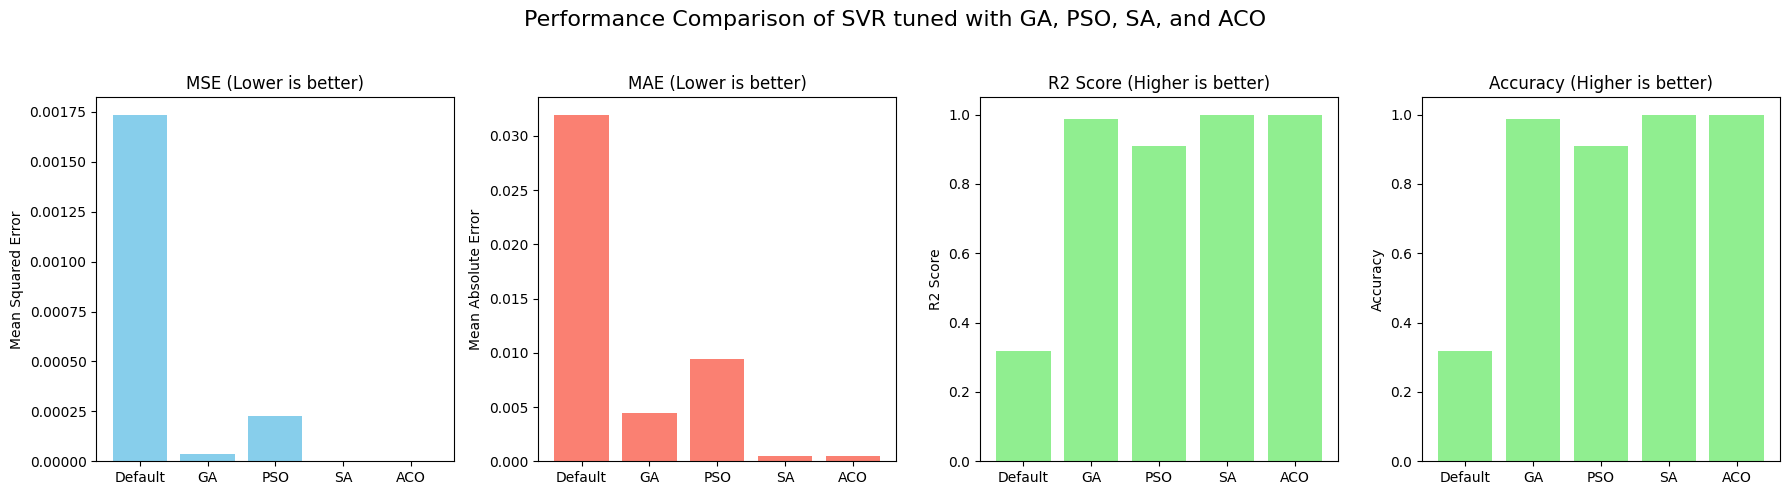

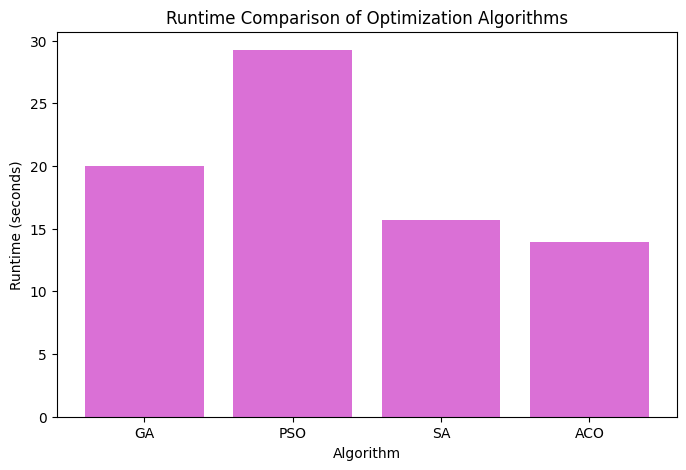

In [ ]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.optimize import dual_annealing
from sklearn.feature_selection import SelectKBest, f_classif  # Use f_regression for regression tasks
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

import pygad          # For Genetic Algorithm (GA)
import pyswarms as ps # For Particle Swarm Optimization (PSO)

# Load and prepare the dataset
data = pd.read_csv("/content/flights.csv")
print(f'flood.csv : {data.shape}')

X = data.drop(labels=['FloodProbability'], axis=1)
Y = data['FloodProbability']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

# Define the objective function for hyperparameter tuning.
# The goal is to minimize the cross-validation MSE for SVR.
def objective_function(params):
    # Unpack parameters: [C, epsilon, gamma]
    C, epsilon, gamma = params
    # Ensure parameters are positive; otherwise, return a large penalty.
    if C <= 0 or epsilon <= 0 or gamma <= 0:
        return 1e6
    model = SVR(kernel='rbf', C=C, epsilon=epsilon, gamma=gamma)
    # Use 3-fold CV; note that cross_val_score returns negative MSE.
    scores = cross_val_score(model, X_train, Y_train, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
    mse = -np.mean(scores)
    return mse

# Define parameter bounds:
# C in [1e-3, 1e3], epsilon in [1e-3, 1], gamma in [1e-4, 1]
bounds = [(1e-3, 1e3), (1e-3, 1.0), (1e-4, 1.0)]

# -----------------------
# 1. Genetic Algorithm (GA) using pygad
# -----------------------
def ga_fitness_func(ga_instance, solution, solution_idx):
    mse = objective_function(solution)
    return -mse

start_time = time.time()
ga_instance = pygad.GA(num_generations=100,
                       num_parents_mating=10,
                       fitness_func=ga_fitness_func,
                       sol_per_pop=20,
                       num_genes=3,
                       # Define the search space for each gene (hyperparameter)
                       gene_space=[{'low': bounds[0][0], 'high': bounds[0][1]},
                                   {'low': bounds[1][0], 'high': bounds[1][1]},
                                   {'low': bounds[2][0], 'high': bounds[2][1]}],
                       mutation_probability=0.1,
                       random_mutation_min_val=0.0,
                       random_mutation_max_val=1.0,
                       suppress_warnings=True)
ga_instance.run()
ga_runtime = time.time() - start_time

solution_ga, fitness_ga, _ = ga_instance.best_solution()
best_params_ga = solution_ga
print("\nGA Optimization:")
print("Best Parameters: ", best_params_ga)
print("Best CV MSE: ", -fitness_ga)
print("GA runtime (s):", ga_runtime)

# -----------------------
# 2. Particle Swarm Optimization (PSO) using pyswarms
# -----------------------
def pso_objective(x):
    # x is an array with shape (n_particles, dimensions)
    n_particles = x.shape[0]
    results = []
    for i in range(n_particles):
        results.append(objective_function(x[i]))
    return np.array(results)

# Setup bounds for PSO
lower_bounds = np.array([b[0] for b in bounds])
upper_bounds = np.array([b[1] for b in bounds])
bounds_pso = (lower_bounds, upper_bounds)

options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
optimizer = ps.single.GlobalBestPSO(n_particles=20, dimensions=3, options=options, bounds=bounds_pso)

start_time = time.time()
best_cost_pso, best_pos_pso = optimizer.optimize(pso_objective, iters=100)
pso_runtime = time.time() - start_time

best_params_pso = best_pos_pso
print("\nPSO Optimization:")
print("Best Parameters: ", best_params_pso)
print("Best CV MSE: ", best_cost_pso)
print("PSO runtime (s):", pso_runtime)

# -----------------------
# 3. Simulated Annealing (SA) using dual_annealing from SciPy
# -----------------------
start_time = time.time()
result_sa = dual_annealing(objective_function, bounds, maxiter=100)
sa_runtime = time.time() - start_time

best_params_sa = result_sa.x
best_cost_sa = result_sa.fun
print("\nSA Optimization:")
print("Best Parameters: ", best_params_sa)
print("Best CV MSE: ", best_cost_sa)
print("SA runtime (s):", sa_runtime)

# -----------------------
# 4. Ant Colony Optimization (ACO) implemented as ACOR (a simplified version)
# -----------------------
def acor(objective_func, bounds, archive_size=20, max_iter=100, samples_per_iter=10, q=0.5):
    dim = len(bounds)
    # Initialize archive with random solutions within bounds
    archive = np.array([np.array([np.random.uniform(low, high) for (low, high) in bounds])
                        for _ in range(archive_size)])
    costs = np.array([objective_func(sol) for sol in archive])

    best_cost = np.min(costs)
    best_solution = archive[np.argmin(costs)]

    for it in range(max_iter):
        # Sort archive by cost (lower is better)
        sorted_indices = np.argsort(costs)
        archive = archive[sorted_indices]
        costs = costs[sorted_indices]

        # Compute weights based on rank
        ranks = np.arange(archive_size)
        weights = np.exp(-((ranks)**2) / (2 * (q * archive_size)**2))
        weights = weights / np.sum(weights)

        new_solutions = []
        for _ in range(samples_per_iter):
            # Choose one solution from the archive according to the weights
            idx = np.random.choice(archive_size, p=weights)
            selected = archive[idx]
            new_sol = np.zeros(dim)
            # For each dimension, add Gaussian noise based on the standard deviation of the archive
            for d in range(dim):
                std_d = np.std(archive[:, d])
                if std_d == 0:
                    std_d = 1e-6
                new_sol[d] = np.random.normal(selected[d], std_d)
                # Keep the new solution within the bounds
                new_sol[d] = np.clip(new_sol[d], bounds[d][0], bounds[d][1])
            new_solutions.append(new_sol)
        new_solutions = np.array(new_solutions)
        new_costs = np.array([objective_func(sol) for sol in new_solutions])

        # Combine and select the best archive_size solutions
        combined_archive = np.vstack((archive, new_solutions))
        combined_costs = np.hstack((costs, new_costs))
        sorted_indices = np.argsort(combined_costs)
        archive = combined_archive[sorted_indices][:archive_size]
        costs = combined_costs[sorted_indices][:archive_size]

        if np.min(costs) < best_cost:
            best_cost = np.min(costs)
            best_solution = archive[np.argmin(costs)]

    return best_solution, best_cost

start_time = time.time()
best_params_aco, best_cost_aco = acor(objective_function, bounds, archive_size=20, max_iter=50, samples_per_iter=10, q=0.5)
aco_runtime = time.time() - start_time

print("\nACO Optimization:")
print("Best Parameters: ", best_params_aco)
print("Best CV MSE: ", best_cost_aco)
print("ACO runtime (s):", aco_runtime)

# -----------------------
# Evaluate each tuned SVR model on the test set
# -----------------------
def evaluate_model(params):
    C, epsilon, gamma = params
    model = SVR(kernel='rbf', C=C, epsilon=epsilon, gamma=gamma)
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(Y_test, y_pred)
    mae = mean_absolute_error(Y_test, y_pred)
    r2 = r2_score(Y_test, y_pred)
    accuracy = model.score(X_test, Y_test)
    return mse, mae, r2, accuracy

# Evaluate default SVR (with library defaults) as a baseline
default_model = SVR(kernel='rbf')
default_model.fit(X_train, Y_train)
y_pred_default = default_model.predict(X_test)
default_mse = mean_squared_error(Y_test, y_pred_default)
default_mae = mean_absolute_error(Y_test, y_pred_default)
default_r2 = r2_score(Y_test, y_pred_default)
default_accuracy = default_model.score(X_test, Y_test)
print("\nDefault SVR Performance:")
print("MSE:", default_mse)
print("MAE:", default_mae)
print("R2:", default_r2)
print("Accuracy:", default_accuracy)

# Get performance metrics for each metaheuristic approach
metrics_ga  = evaluate_model(best_params_ga)
metrics_pso = evaluate_model(best_params_pso)
metrics_sa  = evaluate_model(best_params_sa)
metrics_aco = evaluate_model(best_params_aco)

# Store results in a dictionary: each tuple is (MSE, MAE, R2, Accuracy)
results = {
    "Default": (default_mse, default_mae, default_r2, default_accuracy),
    "GA": metrics_ga,
    "PSO": metrics_pso,
    "SA": metrics_sa,
    "ACO": metrics_aco
}

# -----------------------
# Plot performance comparisons for each metric
# -----------------------
algorithms = list(results.keys())
mse_vals = [results[alg][0] for alg in algorithms]
mae_vals = [results[alg][1] for alg in algorithms]
r2_vals  = [results[alg][2] for alg in algorithms]
acc_vals = [results[alg][3] for alg in algorithms]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].bar(algorithms, mse_vals, color='skyblue')
axes[0].set_title("MSE (Lower is better)")
axes[0].set_ylabel("Mean Squared Error")

axes[1].bar(algorithms, mae_vals, color='salmon')
axes[1].set_title("MAE (Lower is better)")
axes[1].set_ylabel("Mean Absolute Error")

axes[2].bar(algorithms, r2_vals, color='lightgreen')
axes[2].set_title("R2 Score (Higher is better)")
axes[2].set_ylabel("R2 Score")

axes[3].bar(algorithms, acc_vals, color='lightgreen')
axes[3].set_title("Accuracy (Higher is better)")
axes[3].set_ylabel("Accuracy")

plt.suptitle("Performance Comparison of SVR tuned with GA, PSO, SA, and ACO", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("Performance.png")
plt.show()

# -----------------------
# Plot runtime comparison for each optimization algorithm
# -----------------------
runtimes = {
    "GA": ga_runtime,
    "PSO": pso_runtime,
    "SA": sa_runtime,
    "ACO": aco_runtime
}

plt.figure(figsize=(8, 5))
plt.bar(list(runtimes.keys()), list(runtimes.values()), color='orchid')
plt.title("Runtime Comparison of Optimization Algorithms")
plt.xlabel("Algorithm")
plt.ylabel("Runtime (seconds)")
plt.savefig("Runtime.png")
plt.show()
